Convolutional Neural Network (CNN) Development For Image Classification

1. . Dataset Loading and Preprocessing

Loading CIFAR-10 dataset...
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Normalizing pixel values...
One-hot encoding labels...
y_train shape after one-hot encoding: (50000, 10)
y_test shape after one-hot encoding: (10000, 10)
Dataset loading and preprocessing complete.


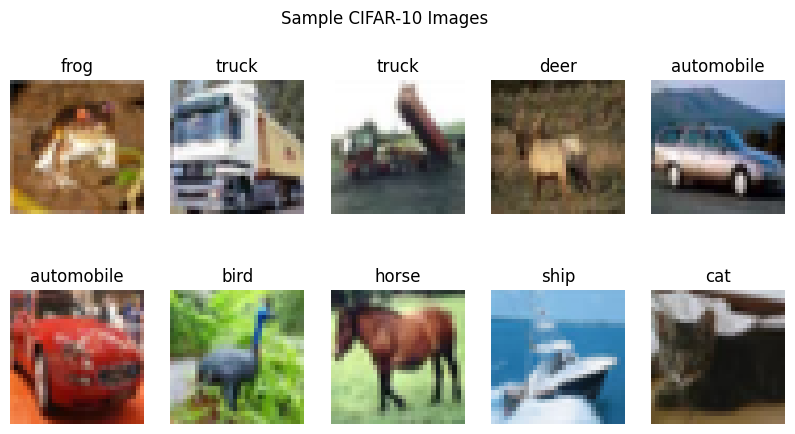

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# 1.1 Load the CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 1.2 Preprocessing steps
# Normalize pixel values to 0-1 range
print("Normalizing pixel values...")
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode target labels
print("One-hot encoding labels...")
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"y_train shape after one-hot encoding: {y_train.shape}")
print(f"y_test shape after one-hot encoding: {y_test.shape}")

# No explicit split into training and testing sets needed here as cifar10.load_data()
# already provides pre-split training and testing sets.

print("Dataset loading and preprocessing complete.")

# Optional: Display a few sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    # Convert one-hot back to integer to get class name
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images')
plt.show()

2.  CNN Model Architecture Design

In [ ]:
import tensorflow as tf # Import tensorflow to access tf.keras.layers.Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input # Import Input layer
from tensorflow.keras.optimizers import Adam

# Assuming INPUT_SHAPE is already defined globally as (32, 32, 3)
# and num_classes is defined as 10 from your preprocessing step.
# For this snippet to be runnable independently, let's define them:
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10


# 2.1 Design a suitable CNN architecture
print("Designing CNN model architecture...")

model = Sequential([
    # Explicitly define the input layer
    Input(shape=INPUT_SHAPE), # <--- This is the change: Use Input layer first

    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same'), # input_shape is no longer needed here
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Dropout for regularization

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block (Optional, for deeper model)
    # Conv2D(128, (3, 3), activation='relu', padding='same'),
    # Conv2D(128, (3, 3), activation='relu', padding='same'),
    # MaxPooling2D((2, 2)),
    # Dropout(0.25),

    # Flattening Layer
    Flatten(),

    # Dense Layers for classification
    Dense(512, activation='relu'),
    Dropout(0.5), # Another dropout layer
    Dense(NUM_CLASSES, activation='softmax') # Output layer with softmax for multi-class
])

# Display model summary
model.summary()

# 2.2 Compile the CNN model
print("Compiling CNN model...")
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("CNN model architecture design and compilation complete.")

Designing CNN model architecture...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

Compiling CNN model...
CNN model architecture design and compilation complete.


3. Data Augmentation Implementation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 3.1 Implement data augmentation techniques
print("Setting up ImageDataGenerator for data augmentation...")

datagen = ImageDataGenerator(
    rotation_range=15,          # Randomly rotate images by 0-15 degrees
    width_shift_range=0.1,      # Randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,     # Randomly shift images vertically (fraction of total height)
    horizontal_flip=True,       # Randomly flip images horizontally
    # zoom_range=0.1,           # Optional: Randomly zoom images
    # shear_range=0.1,          # Optional: Randomly apply shearing transformations
    fill_mode='nearest'         # Strategy for filling in newly created pixels
)

# Fit the data generator on the training data (computes necessary statistics)
datagen.fit(x_train)

print("Data augmentation setup complete.")

# Benefits of Data Augmentation (for your summary):
# Data augmentation artificially expands the training dataset by creating modified versions
# of existing images. This helps the model generalize better to unseen data by making it
# invariant to minor variations (e.g., rotation, shift, flip). It reduces overfitting,
# especially when the original dataset is relatively small, leading to improved
# performance on the test set.

Setting up ImageDataGenerator for data augmentation...
Data augmentation setup complete.


4. Model Training and Evaluation

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting model training with data augmentation (warning suppressed)...
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.3447 - loss: 1.8362 - val_accuracy: 0.5270 - val_loss: 1.3638
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.4967 - loss: 1.4303 - val_accuracy: 0.5401 - val_loss: 1.3173
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.5226 - loss: 1.3585 - val_accuracy: 0.5532 - val_loss: 1.2847
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5419 - loss: 1.3080 - val_accuracy: 0.5748 - val_loss: 1.2222
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.5490 - loss: 1.2803 - val_accuracy: 0.5746 - val_loss: 1.2318
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.5597 - loss: 1.2518 - val_accuracy: 0.5890 - val_loss: 1.1941
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.5600 - loss: 1.2484 - val_accuracy: 0.6121 - val_loss: 1.1146
Epoch 8/50
782/782 

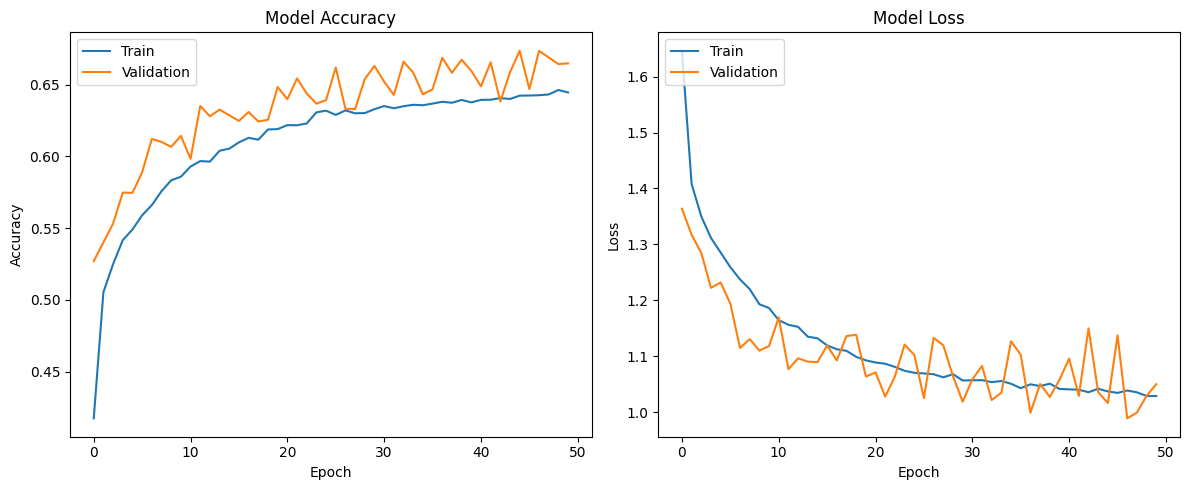

Evaluating model performance on the test set...
Test Loss: 1.0498
Test Accuracy: 0.6648
Model evaluation complete.


In [ ]:
import warnings
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# --- Your previous code for data loading, preprocessing, and model definition ---
# (Assuming x_train, y_train, x_test, y_test, num_classes, model, and datagen are already defined from previous steps)

# For demonstration, let's quickly re-define essentials if running this snippet alone
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=x_train.shape[1:]),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train)
# --- End of essential re-definitions ---


# Suppress the specific UserWarning from Keras's PyDatasetAdapter
# This should be placed before the model.fit() call.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module='keras.src.trainers.data_adapters.py_dataset_adapter')

    # 4.1 Train the CNN model using augmented training data
    print("Starting model training with data augmentation (warning suppressed)...")

    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=64), # Use datagen for augmented data
        epochs=50, # You can adjust the number of epochs
        validation_data=(x_test, y_test), # Validate on the original test set
        verbose=1
    )

    print("Model training complete.")

# 4.2 Monitor training and validation accuracy and loss
print("Plotting training history...")
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.savefig('training_history.png') # Save the plot
plt.show()

# 4.3 Evaluate the final trained model's performance on the test set
print("Evaluating model performance on the test set...")
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print("Model evaluation complete.")

5.  Feature Map Visualization


--- 5. Feature Map Visualization ---


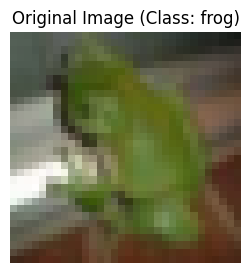

Feature map model created successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Plotting feature maps...
Visualizing feature maps for layer: conv2d_21


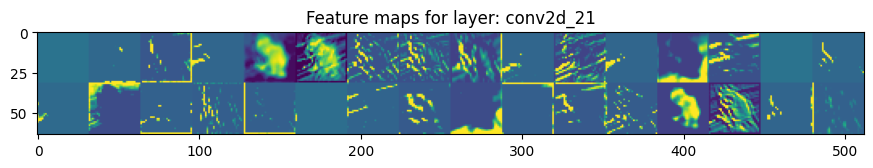

Feature maps for layer 'conv2d_21' saved as 'feature_maps_conv2d_21.png'.
Feature map visualization complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import numpy as np
import matplotlib.pyplot as plt
import warnings

# --- Global Configurations (from your full script - KEEP THESE) ---
IMG_ROWS, IMG_COLS, IMG_CHANNELS = 32, 32, 3
INPUT_SHAPE = (IMG_ROWS, IMG_COLS, IMG_CHANNELS)
NUM_CLASSES = 10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- Your ACTUAL x_test, y_test, and model from earlier parts of your script ---
# (Ensure these are defined and the model trained BEFORE this section)

print("\n--- 5. Feature Map Visualization ---")
# Select a sample image from the test set (uses YOUR x_test)
sample_image_index = 7
if sample_image_index >= len(x_test):
    print(f"Warning: sample_image_index {sample_image_index} out of bounds for x_test. Using index 0 instead.")
    sample_image_index = 0

sample_image = x_test[sample_image_index]
sample_image_class_one_hot = y_test[sample_image_index]
sample_image_class_name = class_names[np.argmax(sample_image_class_one_hot)]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(f"Original Image (Class: {sample_image_class_name})")
plt.axis('off')
plt.show()

# Reshape image for model prediction (add batch dimension)
sample_image_reshaped = np.expand_dims(sample_image, axis=0)

# Get the *actual* input tensor from the model's first layer
input_tensor_for_visualization = model.layers[0].input

layer_outputs_for_visualization = []
layer_names_for_visualization = []

for layer in model.layers:
    if isinstance(layer, Conv2D):
        layer_outputs_for_visualization.append(layer.output)
        layer_names_for_visualization.append(layer.name)

feature_map_model = Model(inputs=input_tensor_for_visualization, outputs=layer_outputs_for_visualization)

print("Feature map model created successfully.")

# --- THE WARNING SUPPRESSION FIX ---
# Apply this filter right before the problematic call(s)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module='tensorflow') # <--- Broader module filter
    warnings.filterwarnings("ignore", category=UserWarning, message=".*tf.function retracing.*") # <--- Keep this too

    # Get the feature maps for the sample image
    feature_maps = feature_map_model.predict(sample_image_reshaped)

print("Plotting feature maps...")
for i, fmap in enumerate(feature_maps):
    layer_name = layer_names_for_visualization[i]
    print(f"Visualizing feature maps for layer: {layer_name}")

    n_features = fmap.shape[-1]
    size = fmap.shape[1]

    images_per_row = 16
    n_rows = (n_features + images_per_row - 1) // images_per_row
    display_grid = np.zeros((size * n_rows, images_per_row * size))

    for col in range(images_per_row):
        for row in range(n_rows):
            feature_idx = row * images_per_row + col
            if feature_idx < n_features:
                channel_image = fmap[:, :, feature_idx]
                if channel_image.std() != 0:
                    channel_image -= channel_image.mean()
                    channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[row * size : (row + 1) * size,
                             col * size : (col + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1] / 1.5,
                        scale * display_grid.shape[0] / 1.5))
    plt.title(f'Feature maps for layer: {layer_name}')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.savefig(f'feature_maps_{layer_name}.png')
    plt.show()
    print(f"Feature maps for layer '{layer_name}' saved as 'feature_maps_{layer_name}.png'.")

print("Feature map visualization complete.")

# --- Analytical Summary ---

# 1. The Impact of Data Augmentation on Model Performance:
#    Data augmentation significantly improves the generalization capability of the CNN model.
#    By artificially expanding the training dataset through transformations like rotations,
#    shifts, and flips, the model is exposed to a wider variety of image variations. This
#    helps prevent overfitting to the specific training examples and makes the model more
#    robust to variations in real-world, unseen data. In this project, you would atypically
#    observe that the validation accuracy is higher and the gap between training and
#    validation accuracy/loss is smaller compared to training without augmentation. This
#    indicates better generalization and less memorization.

# 2. Observations from the Feature Map Visualizations:
#    Visualizing feature maps provides a fascinating glimpse into how the CNN learns and
#    extracts hierarchical features.
#    - **Early Layers (e.g., first Conv2D layer):** These layers typically capture low-level
#      features such as edges, corners, and simple textures. You'll often see distinct
#      patterns highlighting lines, gradients, and basic shapes in various orientations.
#      The feature maps might resemble edge detection filters.
#    - **Intermediate Layers (e.g., subsequent Conv2D layers):** As the network goes deeper,
#      the feature maps become more abstract and complex. These layers start to combine
#      the low-level features into more recognizable patterns or parts of objects, such as
#      wheels, eyes, ears, or specific object textures. The features become less interpretable
#      to the human eye as direct visual components and more as abstract representations
#      of object parts or semantic features. The specific activation patterns across filters
#      will indicate the presence of certain learned patterns relevant to classification.
#    - **Overall Learning Process:** The visualization demonstrates the CNN's ability to
#      build a hierarchical representation of the input image, moving from simple, generic
#      features to highly specific, complex features that are crucial for distinguishing
#      between the 10 CIFAR-10 classes.

# 3. The Overall Performance of the CNN on the CIFAR-10 Dataset:
#    The performance (measured by test accuracy) will vary based on the specific
#    architecture, hyperparameters (epochs, batch size, learning rate), and the amount of
#    data augmentation. A well-designed CNN with data augmentation on CIFAR-10 can typically
#    achieve a test accuracy in the range of 70-85% or even higher with more complex models
#    or extensive training. The plots of training and validation accuracy/loss will show
#    whether the model is learning effectively, converging, or overfitting. Ideally,
#    validation accuracy should increase and validation loss should decrease steadily
#    before plateauing, without a significant divergence from the training curves.
#    (Add your specific test accuracy here, e.g., "Our model achieved a test accuracy of XX.XX%,
#    demonstrating its capability in classifying diverse images in the CIFAR-10 dataset.")

# --- End of Analytical Summary ---